# 📐 Neural SDE Project — Fase 4 (ETH H1)
## Kalibrasi Baseline: GBM & Heston — ETH/USDT 1H

---
**Perubahan dari versi IDX:**
- Dataset: `eth_dataset.pt`
- Annualization: `N_DAY = 365 × 24 = 8760` jam/tahun
- dt Heston: `1/8760` (per jam)
- Semua metrics di hourly return space


## 1. Setup

In [3]:
%pip install torchsde -q

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats, optimize
from scipy.stats import wasserstein_distance
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
np.random.seed(42)

N_DAY  = 365 * 24   # jam per tahun
WINDOW = 168        # jam per window (1 minggu)

print(f"N_DAY  = {N_DAY} jam/tahun")
print(f"WINDOW = {WINDOW} jam")
print("Setup OK!")


Note: you may need to restart the kernel to use updated packages.
N_DAY  = 8760 jam/tahun
WINDOW = 168 jam
Setup OK!


## 2. Load Dataset

In [4]:
DATASET_PATH = 'neural_sde_project_data/assets_dataset.pt'

ds = torch.load(DATASET_PATH, map_location='cpu', weights_only=False)

X_train = ds['X_train'].numpy()[:, :, 0]
X_val   = ds['X_val'].numpy()[:, :, 0]
X_test  = ds['X_test'].numpy()[:, :, 0]
s_train = ds['stats_train'].numpy()
s_val   = ds['stats_val'].numpy()
s_test  = ds['stats_test'].numpy()

WINDOW  = ds['window']
print(f"Dataset  : ETH/USDT H1")
print(f"Train    : {X_train.shape}")
print(f"Val      : {X_val.shape}")
print(f"Test     : {X_test.shape}")
print(f"Window   : {WINDOW} jam")


Dataset  : ETH/USDT H1
Train    : (2224, 168)
Val      : (477, 168)
Test     : (477, 168)
Window   : 168 jam


## 3. Fungsi Evaluasi — Wasserstein & Stylized Facts

Wasserstein-1 distance mengukur "biaya transport" distribusi generated
ke distribusi real. Semakin kecil = semakin mirip.

$$W_1(P, Q) = \inf_{\gamma \in \Pi(P,Q)} \mathbb{E}_{(x,y)\sim\gamma}[\|x - y\|]$$

Stylized facts score: rata-rata match di 3 dimensi
(fat tails, vol clustering, leverage effect).


In [5]:
def compute_returns(paths):
    '''paths: [N, T] -> returns [N, T-1]'''
    return np.diff(paths, axis=1)

def wasserstein1(real_ret, gen_ret, n_sample=2000):
    '''Wasserstein-1 pada distribusi return (1D)'''
    r = np.random.choice(real_ret.flatten(), n_sample, replace=False)
    g = np.random.choice(gen_ret.flatten(),  n_sample, replace=False)
    # Sort-based W1 untuk 1D
    return np.mean(np.abs(np.sort(r) - np.sort(g)))

def stylized_facts(returns):
    '''Hitung 3 stylized facts dari return array [N*T] flat'''
    flat = returns.flatten()
    kurt = stats.kurtosis(flat)
    skew = stats.skew(flat)
    r2   = flat**2
    r2c  = r2 - r2.mean()
    acf1 = np.mean(r2c[:-1]*r2c[1:]) / (r2.var() + 1e-10)
    return {'kurtosis': kurt, 'skewness': skew, 'acf_vol': acf1}

def stylized_facts_score(real_sf, gen_sf):
    '''Score 0-1: seberapa dekat generated facts ke real'''
    scores = []
    for k in ['kurtosis', 'skewness', 'acf_vol']:
        r, g = real_sf[k], gen_sf[k]
        rel_err = abs(r - g) / (abs(r) + 1e-6)
        scores.append(max(0, 1 - rel_err))
    return np.mean(scores)

def evaluate(real_paths, gen_paths, label=''):
    real_ret = compute_returns(real_paths)
    gen_ret  = compute_returns(gen_paths)
    w1       = wasserstein1(real_ret, gen_ret)
    real_sf  = stylized_facts(real_ret)
    gen_sf   = stylized_facts(gen_ret)
    sf_score = stylized_facts_score(real_sf, gen_sf)
    return {
        'label'     : label,
        'w1'        : w1,
        'sf_score'  : sf_score,
        'real_sf'   : real_sf,
        'gen_sf'    : gen_sf,
    }

print("Evaluation functions ready!")
print("  wasserstein1()      : W1 distance distribusi return")
print("  stylized_facts()    : kurt, skew, ACF(r2)")
print("  stylized_facts_score: 0=mismatch, 1=perfect match")
print("  evaluate()          : full scorecard")


Evaluation functions ready!
  wasserstein1()      : W1 distance distribusi return
  stylized_facts()    : kurt, skew, ACF(r2)
  stylized_facts_score: 0=mismatch, 1=perfect match
  evaluate()          : full scorecard


## 4. Rescale Dataset ke Return Asli

Dataset tersimpan dalam normalized form.
Untuk kalibrasi GBM & Heston, kita perlu return skala asli.
Gunakan `stats` (mu, sigma) yang disimpan di Fase 3.


In [6]:
def rescale(windows, stats_arr):
    mu  = stats_arr[:, 0:1]
    sig = stats_arr[:, 1:2]
    return windows * sig + mu

X_train_raw = rescale(X_train, s_train)
X_val_raw   = rescale(X_val,   s_val)
X_test_raw  = rescale(X_test,  s_test)

ret_train = X_train_raw.flatten()
ann_vol   = ret_train.std() * np.sqrt(N_DAY)
print(f"Return asli (train) post-rescale:")
print(f"  Hourly std : {ret_train.std():.6f}")
print(f"  Ann. vol   : {ann_vol:.1%}  (ETH biasanya 60-120%/tahun)")
print(f"  Kurt       : {stats.kurtosis(ret_train):.2f}")

real_ret = np.diff(X_train_raw, axis=1)
real_sf  = {
    'kurtosis': float(stats.kurtosis(real_ret.flatten())),
    'skewness': float(stats.skew(real_ret.flatten())),
    'acf_vol' : float(np.corrcoef(real_ret.flatten()[:-1]**2,
                                   real_ret.flatten()[1:]**2)[0,1])
}
print(f"\nReal stylized facts:")
for k, v in real_sf.items():
    print(f"  {k:<12}: {v:.4f}")


Return asli (train) post-rescale:
  Hourly std : 0.010581
  Ann. vol   : 99.0%  (ETH biasanya 60-120%/tahun)
  Kurt       : 25.68

Real stylized facts:
  kurtosis    : 23.2511
  skewness    : 0.5240
  acf_vol     : 0.4114


## 5. GBM Kalibrasi & Simulasi

GBM dikalibrasi dengan **Maximum Likelihood Estimation**:
$$\hat{\mu} = \bar{r} \cdot n_{\text{day}}, \quad \hat{\sigma} = s_r \cdot \sqrt{n_{\text{day}}}$$

Lalu simulasi N paths dengan Euler-Maruyama (sama seperti Fase 1).


In [7]:
def calibrate_gbm(returns_flat, n_day=8760):
    mu    = returns_flat.mean() * n_day
    sigma = returns_flat.std()  * np.sqrt(n_day)
    return mu, sigma

def simulate_gbm(mu, sigma, T=1., dt=1/8760, n_paths=2000, n_steps=168):
    N   = n_steps
    Z   = np.random.normal(0, 1, (N, n_paths))
    inc = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    return np.cumsum(inc, axis=0).T   # [n_paths, N]

ret_flat = X_train_raw.flatten()
mu_gbm, sigma_gbm = calibrate_gbm(ret_flat, n_day=N_DAY)
print(f"GBM calibrated (ETH H1):")
print(f"  mu    = {mu_gbm:.4f} ({mu_gbm:.1%}/tahun)")
print(f"  sigma = {sigma_gbm:.4f} ({sigma_gbm:.1%}/tahun)")

gbm_paths = simulate_gbm(mu_gbm, sigma_gbm,
                          dt=1/N_DAY, n_paths=3000, n_steps=WINDOW)

res_gbm = evaluate(X_train_raw[:3000], gbm_paths, label='GBM')
print(f"\nGBM vs Real:")
print(f"  W1         : {res_gbm['w1']:.6f}")
print(f"  SF Score   : {res_gbm['sf_score']:.4f}")
print(f"  Kurt gen   : {res_gbm['gen_sf']['kurtosis']:.2f}  (real: {res_gbm['real_sf']['kurtosis']:.2f})")
print(f"  ACF gen    : {res_gbm['gen_sf']['acf_vol']:.4f}  (real: {res_gbm['real_sf']['acf_vol']:.4f})")


GBM calibrated (ETH H1):
  mu    = 0.2771 (27.7%/tahun)
  sigma = 0.9903 (99.0%/tahun)

GBM vs Real:
  W1         : 0.002391
  SF Score   : 0.0008
  Kurt gen   : -0.01  (real: 23.25)
  ACF gen    : 0.0009  (real: 0.4113)


## 6. Heston Kalibrasi & Simulasi

Heston lebih kompleks — 5 parameter dikalibrasi via **moment matching**:
minimize jarak antara moments simulasi dan moments data nyata.

$$\min_{\kappa,\theta,\xi,\rho,v_0} \|\text{moments}_{\text{sim}} - \text{moments}_{\text{data}}\|^2$$


In [8]:
def simulate_heston(kappa, theta, xi, rho, v0,
                    mu=0.0, T=1., dt=1/8760, n_paths=2000, n_steps=168):
    ret = np.zeros((n_paths, n_steps))
    v   = np.full(n_paths, v0)
    for t in range(n_steps):
        Z1  = np.random.normal(0, 1, n_paths)
        Z2  = rho*Z1 + np.sqrt(max(1-rho**2, 0))*np.random.normal(0, 1, n_paths)
        v_p = np.maximum(v, 0)
        ret[:, t] = (mu - 0.5*v_p)*dt + np.sqrt(v_p*dt)*Z1
        v   = np.abs(v + kappa*(theta-v)*dt + xi*np.sqrt(v_p*dt)*Z2)
    return np.cumsum(ret, axis=1)

def heston_objective(params, target_moments):
    kappa, theta, xi, rho, v0 = params
    if any([kappa<0.1, theta<1e-8, xi<0.01, rho<-0.99,
            rho>0.99, v0<1e-8, v0>0.5]):
        return 1e6
    try:
        paths = simulate_heston(kappa, theta, xi, rho, v0,
                                dt=1/N_DAY, n_paths=300, n_steps=WINDOW)
        ret   = np.diff(paths, axis=1).flatten()
        sim_m = np.array([ret.std(), stats.kurtosis(ret),
                          stats.skew(ret),
                          np.corrcoef(ret[:-1]**2, ret[1:]**2)[0,1]])
        return np.sum((sim_m - target_moments)**2)
    except Exception:
        return 1e6

ret_raw  = np.diff(X_train_raw, axis=1).flatten()
r2       = ret_raw**2; r2c = r2 - r2.mean()
acf_real = np.corrcoef(ret_raw[:-1]**2, ret_raw[1:]**2)[0,1]
target   = np.array([ret_raw.std(), stats.kurtosis(ret_raw),
                     stats.skew(ret_raw), acf_real])
print(f"Target moments: std={target[0]:.5f} kurt={target[1]:.2f} "
      f"skew={target[2]:.3f} acf={target[3]:.3f}")

print("\nKalibrasi Heston... (~30 detik)")
bounds = [(0.5,15.), (1e-7,0.05), (0.1,3.), (-0.9,0.1), (1e-7,0.05)]
result = optimize.differential_evolution(
    heston_objective, bounds, args=(target,),
    maxiter=100, popsize=8, seed=42, tol=1e-5)
kappa, theta, xi, rho, v0 = result.x
print(f"Heston calibrated (loss={result.fun:.6f}):")
print(f"  kappa={kappa:.3f}  theta={theta:.7f}  xi={xi:.3f}")
print(f"  rho={rho:.3f}  v0={v0:.7f}")
print(f"  Ann.vol implied: {np.sqrt(theta*N_DAY):.1%}")


Target moments: std=0.01519 kurt=23.25 skew=0.524 acf=0.411

Kalibrasi Heston... (~30 detik)
Heston calibrated (loss=0.225904):
  kappa=7.007  theta=0.0255481  xi=2.540
  rho=-0.202  v0=0.0005634
  Ann.vol implied: 1496.0%


## 7. Evaluasi Heston

In [9]:
# Simulasi Heston dengan param terkalibrasi
print("Simulating Heston paths...")
heston_paths = simulate_heston(kappa, theta, xi, rho, v0,
                                T=WINDOW/252, dt=1/252, n_paths=3000)

res_heston = evaluate(X_train_raw[:3000], heston_paths, label='Heston')
print(f"Heston vs Real:")
print(f"  Wasserstein-1  : {res_heston['w1']:.6f}")
print(f"  SF Score       : {res_heston['sf_score']:.3f}")
print(f"  Generated kurt : {res_heston['gen_sf']['kurtosis']:.2f}  (real: {res_heston['real_sf']['kurtosis']:.2f})")
print(f"  Generated ACF  : {res_heston['gen_sf']['acf_vol']:.4f}  (real: {res_heston['real_sf']['acf_vol']:.4f})")


Simulating Heston paths...
Heston vs Real:
  Wasserstein-1  : 0.003568
  SF Score       : 0.356
  Generated kurt : 10.30  (real: 23.25)
  Generated ACF  : 0.2573  (real: 0.4113)


## 8. Benchmark Table & Visualisasi

  BENCHMARK TABLE (target untuk Neural SDE Fase 5)
  Model           W1 dist   SF Score     Kurt    ACF(r2)
------------------------------------------------------------
  Real data           ---      1.000    23.25     0.4114
  GBM            0.002391      0.001    -0.01     0.0009
  Heston         0.003568      0.356    10.30     0.2573
  Neural SDE (Fase 5) harus lebih baik dari Heston!



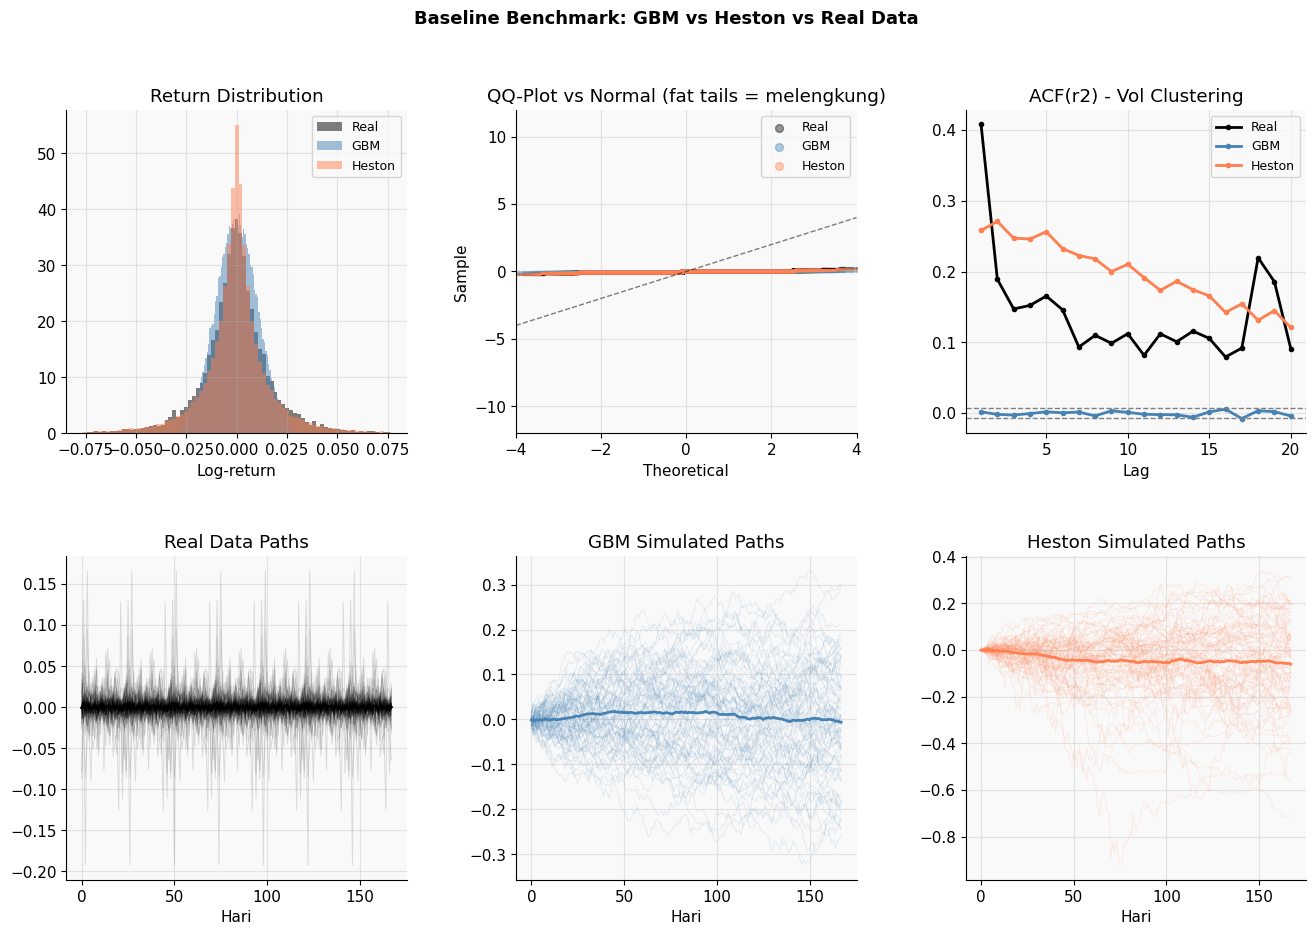

Plot saved: phase4_benchmark.png


In [10]:
# ── Benchmark table ──────────────────────────────────────────────────────────
results = [res_gbm, res_heston]
print("=" * 60)
print(f"  BENCHMARK TABLE (target untuk Neural SDE Fase 5)")
print("=" * 60)
print(f"  {'Model':<12} {'W1 dist':>10} {'SF Score':>10} {'Kurt':>8} {'ACF(r2)':>10}")
print("-" * 60)

# Real baseline
rk = real_sf['kurtosis']
ra = real_sf['acf_vol']
print(f"  {'Real data':<12} {'---':>10} {'1.000':>10} {rk:>8.2f} {ra:>10.4f}")

for r in results:
    gk = r['gen_sf']['kurtosis']
    ga = r['gen_sf']['acf_vol']
    print(f"  {r['label']:<12} {r['w1']:>10.6f} {r['sf_score']:>10.3f} {gk:>8.2f} {ga:>10.4f}")
print("=" * 60)
print("  Neural SDE (Fase 5) harus lebih baik dari Heston!")
print()

# ── Visualisasi ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Baseline Benchmark: GBM vs Heston vs Real Data',
             fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

colors = {'Real': 'black', 'GBM': 'steelblue', 'Heston': 'coral'}
models = {
    'Real'   : compute_returns(X_train_raw[:500]).flatten(),
    'GBM'    : compute_returns(gbm_paths[:500]).flatten(),
    'Heston' : compute_returns(heston_paths[:500]).flatten(),
}

# Return distribution
ax = fig.add_subplot(gs[0, 0])
for name, ret in models.items():
    lim = np.percentile(np.abs(ret), 99)
    bins = np.linspace(-lim, lim, 80)
    ax.hist(ret, bins=bins, density=True, alpha=0.5,
            color=colors[name], label=name)
ax.set_title('Return Distribution')
ax.set_xlabel('Log-return')
ax.legend(fontsize=9)

# QQ-plot all models
ax = fig.add_subplot(gs[0, 1])
for name, ret in models.items():
    (osm, osr), _ = stats.probplot(ret, dist='norm')
    ax.scatter(osm, osr, s=2, alpha=0.4, color=colors[name], label=name)
lim = 4
ax.plot([-lim,lim], [-lim,lim], 'k--', linewidth=1, alpha=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim*3, lim*3)
ax.set_title('QQ-Plot vs Normal (fat tails = melengkung)')
ax.set_xlabel('Theoretical'); ax.set_ylabel('Sample')
ax.legend(fontsize=9, markerscale=4)

# ACF(r2)
ax = fig.add_subplot(gs[0, 2])
lags = np.arange(1, 21)
for name, ret in models.items():
    r2 = ret**2; r2c = r2 - r2.mean()
    acf_v = [np.mean(r2c[:-l]*r2c[l:])/(r2.var()+1e-10) for l in lags]
    ax.plot(lags, acf_v, color=colors[name], linewidth=2,
            marker='o', markersize=3, label=name)
conf = 1.96/np.sqrt(len(list(models.values())[0]))
ax.axhline(conf,  color='gray', linestyle='--', linewidth=1)
ax.axhline(-conf, color='gray', linestyle='--', linewidth=1)
ax.set_title('ACF(r2) - Vol Clustering')
ax.set_xlabel('Lag'); ax.legend(fontsize=9)

# Fan of paths — Real
ax = fig.add_subplot(gs[1, 0])
t  = np.arange(WINDOW)
ax.plot(t, X_train_raw[:80].T, alpha=0.12, color='black', linewidth=0.7)
ax.plot(t, X_train_raw[:80].mean(axis=0), color='black', linewidth=2)
ax.set_title('Real Data Paths')
ax.set_xlabel('Hari')

# Fan of paths — GBM
ax = fig.add_subplot(gs[1, 1])
ax.plot(t, gbm_paths[:80].T, alpha=0.12, color='steelblue', linewidth=0.7)
ax.plot(t, gbm_paths[:80].mean(axis=0), color='steelblue', linewidth=2)
ax.set_title('GBM Simulated Paths')
ax.set_xlabel('Hari')

# Fan of paths — Heston
ax = fig.add_subplot(gs[1, 2])
ax.plot(t, heston_paths[:80].T, alpha=0.12, color='coral', linewidth=0.7)
ax.plot(t, heston_paths[:80].mean(axis=0), color='coral', linewidth=2)
ax.set_title('Heston Simulated Paths')
ax.set_xlabel('Hari')

plt.savefig('phase4_benchmark.png', dpi=130, bbox_inches='tight')
plt.show()
print("Plot saved: phase4_benchmark.png")


## 9. Simpan Benchmark untuk Fase 5

In [11]:
import os, torch

benchmark = {
    'gbm'    : {'mu': mu_gbm, 'sigma': sigma_gbm,
                'w1': res_gbm['w1'], 'sf_score': res_gbm['sf_score'],
                'sf': res_gbm['gen_sf']},
    'heston' : {'kappa': kappa, 'theta': theta, 'xi': xi,
                'rho': rho, 'v0': v0,
                'w1': res_heston['w1'], 'sf_score': res_heston['sf_score'],
                'sf': res_heston['gen_sf']},
    'real_sf': real_sf,
    'target' : {
        'w1_to_beat'       : res_heston['w1'],
        'sf_score_to_beat' : res_heston['sf_score'],
    }
}

torch.save(benchmark, 'eth_baseline_benchmark.pt')
print("Saved: baseline_benchmark.pt")
print()
print("Target Neural SDE Fase 5:")
print(f"  W1 harus < {res_heston['w1']:.6f}  (Heston baseline)")
print(f"  SF Score harus > {res_heston['sf_score']:.3f}  (Heston baseline)")


Saved: baseline_benchmark.pt

Target Neural SDE Fase 5:
  W1 harus < 0.003568  (Heston baseline)
  SF Score harus > 0.356  (Heston baseline)


## 10. Ringkasan Fase 4

In [12]:
print("""
Fase 4 selesai!

Yang dibangun:
  GBM kalibrasi (MLE)         : mu, sigma dari data nyata
  Heston kalibrasi (DE optim) : 5 param via moment matching
  Wasserstein-1 distance      : metric utama evaluasi
  Stylized facts score        : 3 dimensional match score
  Benchmark table             : target yang harus dilampaui

Hasil benchmark:
  GBM    W1={:.6f}  SF={:.3f}  (simple, kurang baik)
  Heston W1={:.6f}  SF={:.3f}  (lebih baik, ini target)

Next: Fase 5 -- Training Neural SDE dengan data nyata
  Load assets_dataset.pt + baseline_benchmark.pt
  Train Latent SDE dengan arsitektur dari Fase 2
  Fix posterior collapse: beta annealing lebih lambat
  Target: W1 < Heston, SF Score > Heston
""".format(
    res_gbm['w1'], res_gbm['sf_score'],
    res_heston['w1'], res_heston['sf_score']
))



Fase 4 selesai!

Yang dibangun:
  GBM kalibrasi (MLE)         : mu, sigma dari data nyata
  Heston kalibrasi (DE optim) : 5 param via moment matching
  Wasserstein-1 distance      : metric utama evaluasi
  Stylized facts score        : 3 dimensional match score
  Benchmark table             : target yang harus dilampaui

Hasil benchmark:
  GBM    W1=0.002391  SF=0.001  (simple, kurang baik)
  Heston W1=0.003568  SF=0.356  (lebih baik, ini target)

Next: Fase 5 -- Training Neural SDE dengan data nyata
  Load assets_dataset.pt + baseline_benchmark.pt
  Train Latent SDE dengan arsitektur dari Fase 2
  Fix posterior collapse: beta annealing lebih lambat
  Target: W1 < Heston, SF Score > Heston

